In [2]:
import sys
sys.path.append("../src")
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.ensemble import ObliqueRandomForestRegressor
import xgboost as xgb

## Data Generation

In [3]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 100000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [4]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


In [317]:
T_initial = 50
actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 100000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 8515)
state_posencode_oh = position_encoder(states[:,0], type="onehot")
new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
X_train = new_state_oh[:T_initial,:]
Y_train = irewards[:T_initial]
model = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="exact",     # or "exact" (slower, RAM heavy)
    n_jobs = -1,
    learning_rate=0.05, max_depth=10,
    subsample=0.8, colsample_bytree=0.8,
    n_estimators=100, eval_metric="rmse"
)
model.fit(X_train, Y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


In [318]:
ADD_TREES = 100
batch = 50
for i in range(9):
    t_initial = T_initial+batch*i
    t_end = T_initial+batch*(i+1)
    # print(t_initial,t_end)
    Xn =new_state_oh[t_initial:t_end,:]
    yn = irewards[t_initial:t_end]

    step = xgb.XGBRegressor(
        objective="reg:squarederror",
        tree_method="exact",
        n_jobs=1,
        learning_rate=0.05,
        max_depth=10,
        subsample=0.8,
        colsample_bytree=0.8,
        n_estimators=ADD_TREES,
        eval_metric="rmse",
        # random_state=0
    )
    step.fit(Xn, yn, xgb_model=model) 
    model = step
dump_list = model.get_booster().get_dump()
num_trees = len(dump_list)
print(num_trees)

1000


1000 4.0
1000 [np.float64(4.0), 3, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1] 101
1.207832777578171


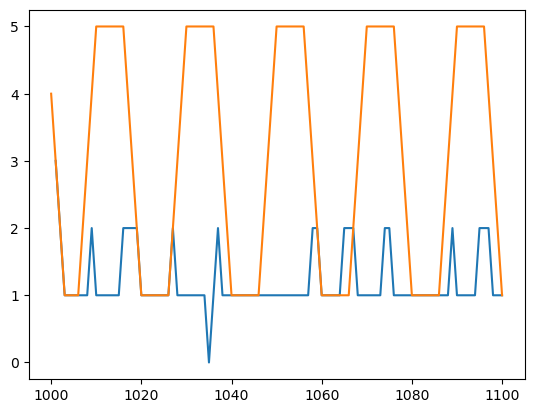

In [319]:
T = 1000
t_prime = 6
gamma = 0.5
current_state = states[T,0]
print(T,current_state)
future_states = [current_state]
for delta_t in range(100):
    df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  t_prime+1))

    for i in range(t_prime+1):
        cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
        curr_time = T+1+delta_t+i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
        features = np.hstack([cand_pe,time_emb])
        irewards_pred[:,i] = model.predict(features)

    # # Convert to DataFrame for inspection
    reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    # Extract rewards from second column onward (t=1 to t=T)
    rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
    discounts = gamma ** np.arange(1, t_prime+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)
    bext_idx = np.argmax(total_discounted)
    next_state = int(df_all_paths.iloc[bext_idx,1])
    # print(df_all_paths.iloc[bext_idx,:])
    future_states.append(next_state)
    current_state = next_state
    # print(T+delta_t+1,current_state)
print(T,future_states,len(future_states))
# FUTURE_STATE.append(future_states)

irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
preward = compute_normalized_future_rewards(irewards_test,100,0.5)
path, ireward_opt = path_opt(future_states[0], T, 100)
preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
print(pregret)
plt.plot(np.arange(T+1,T+101),future_states[1:])
plt.plot(np.arange(T,T+101),path)
plt.show()

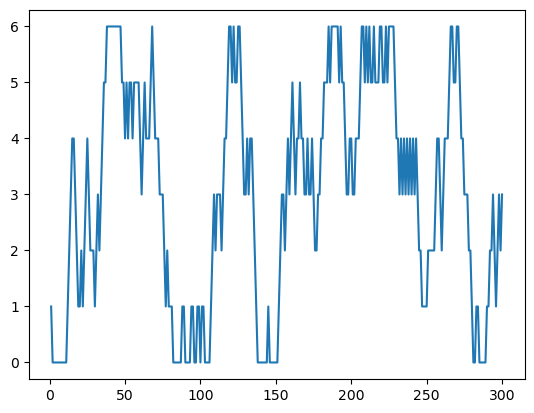

[1.1182529388469735, 0.4703504694938573, 0.0, 0.0, 0.0, 0.0, 0.0]


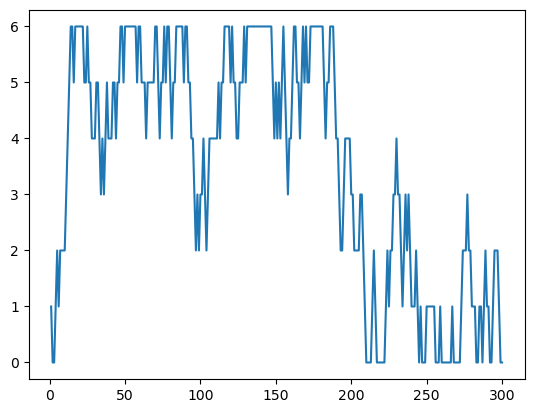

[1.1021543079478844, 1.1622812283794068, 0.31104211769125667, 0.0, 0.0, 0.0, 0.0]


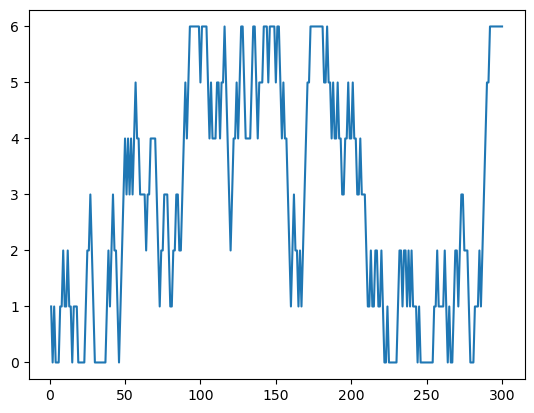

[1.1879204731594621, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


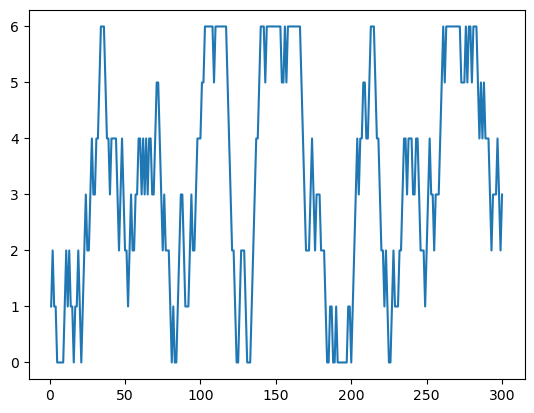

[1.344490288856757, 1.106883833218382, 1.196115677839821, 0.30081399916229884, 0.11118141131374984, 0.0, 0.0]


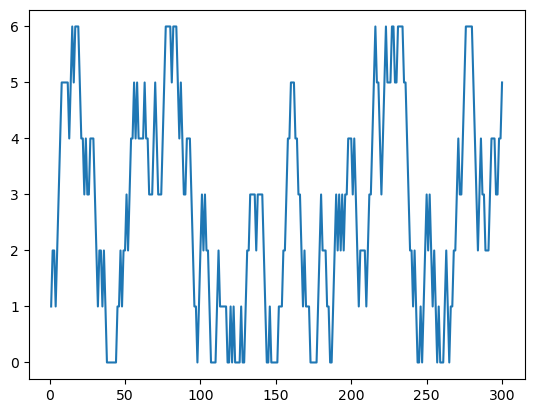

[0.918815887895494, 1.4746929844229124, 1.0226973002929254, 0.1601866240679223, 0.2121132544000403, 0.0, 0.0]


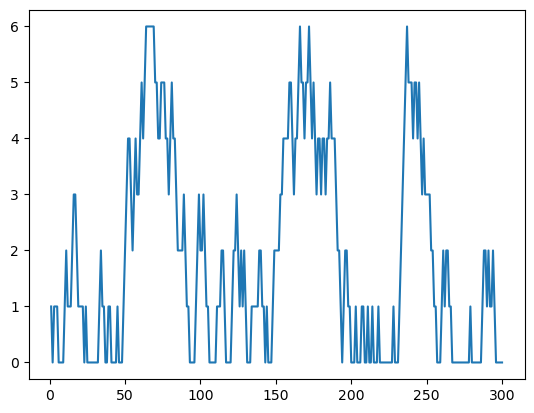

[1.0655543079618544, 1.140743733991101, 0.9963446828378661, 0.7780684963422126, 0.0, 0.0, 0.0]


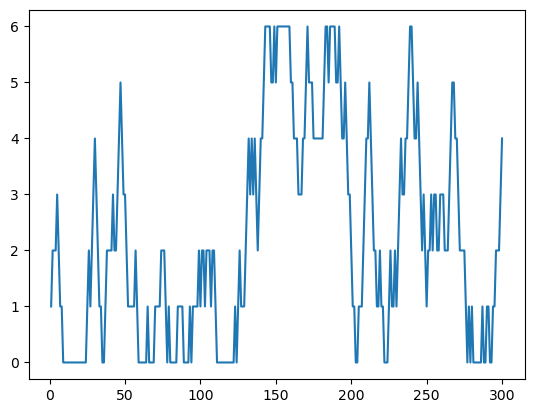

[1.0205543079618544, 0.9335623014037236, 0.796624280402857, 0.15552102381208385, 0.3110420472653502, 0.19440128197761056, 0.0]


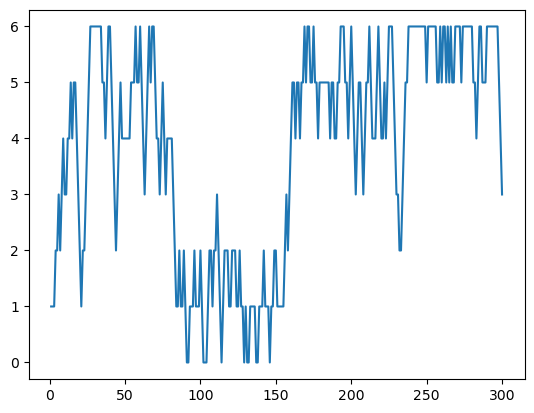

[0.990062077561855, 1.0162614866852406, 0.0, 0.0, 0.0, 0.0, 0.0]


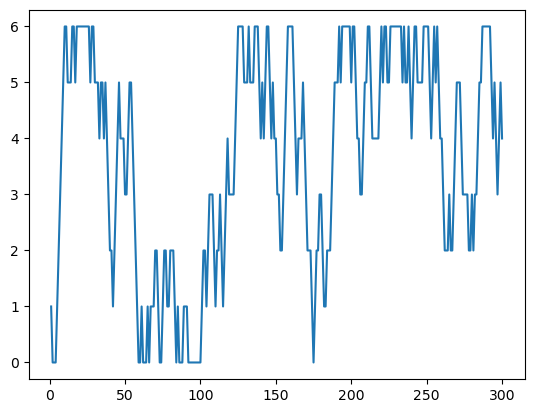

[0.48588361318140555, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


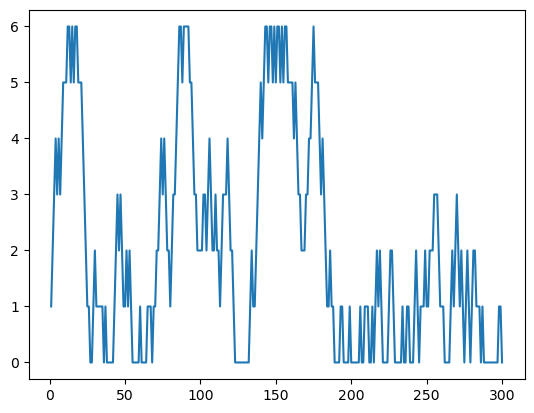

[1.3550644600562123, 1.128669443129878, 1.4093059479777004, 0.3886834391876388, 1.1713190453410263, 0.0, 0.0]


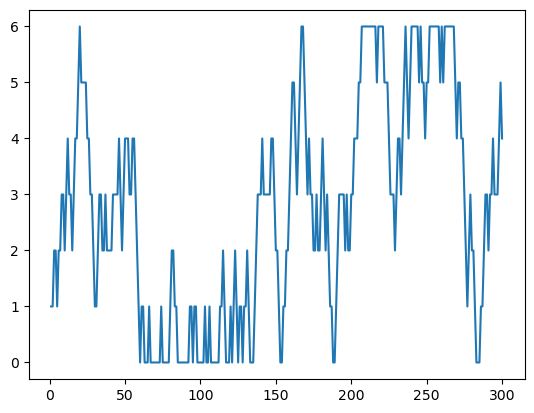

[1.0003043079618543, 0.9241507342631323, 0.009431081971009406, 0.025806457617051706, 0.0, 0.0, 0.0]


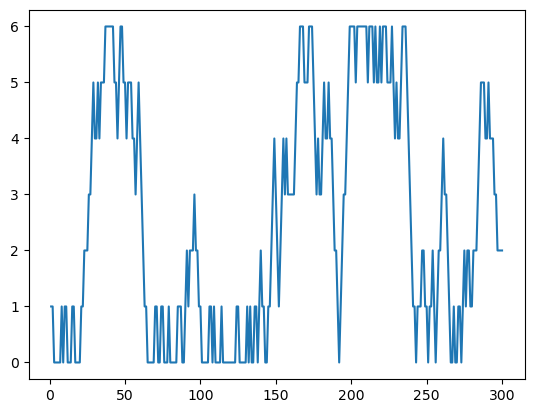

[1.1461645222542451, 0.0, 0.22507325439979695, 0.0, 0.0, 0.0, 0.0]


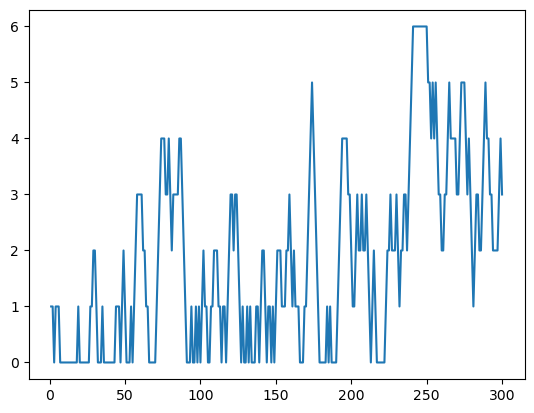

[0.9890543079618546, 1.2342521900493149, 1.0162242896458726, 0.03421449509380494, 0.013413623730623386, 0.0, 0.0]


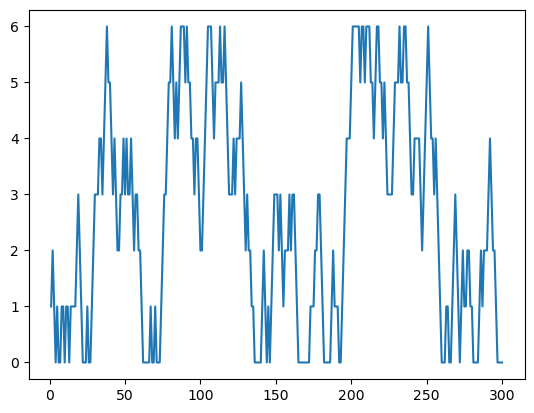

[0.9061390034853031, 0.11974886292467204, 0.0, 0.0072899999999998496, 0.0, 0.0, 0.0]


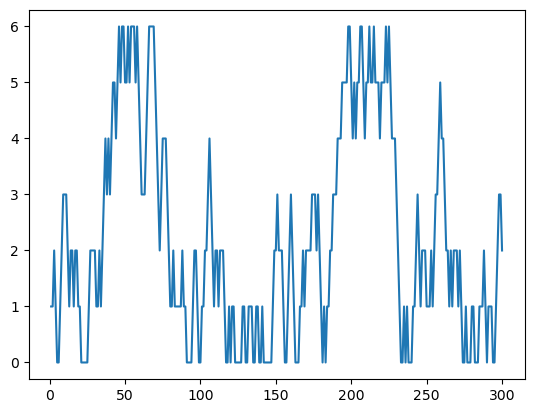

[1.387432496851748, 1.180720899281548, 0.7269683011085226, 0.3347159045849071, 0.0, 0.0, 0.0]


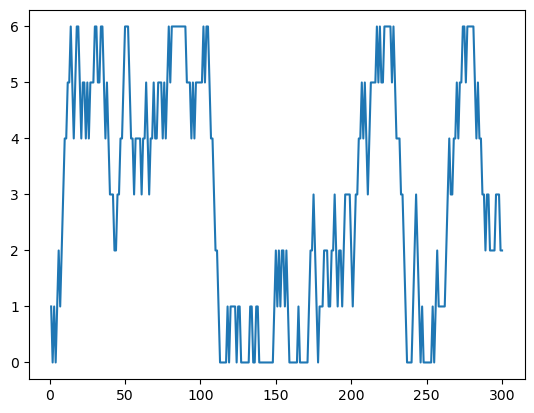

[1.070654307961855, 0.4865162498593867, 0.15591030713755885, 0.0, 0.0, 0.0, 0.0]


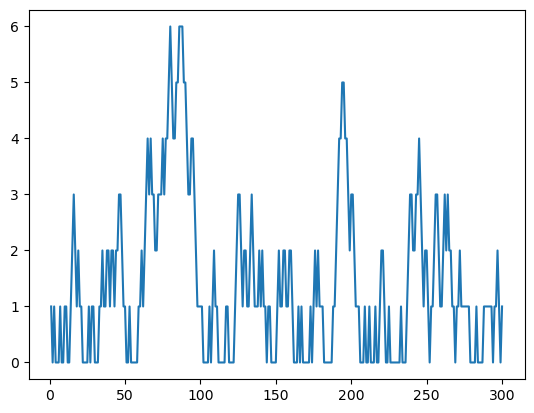

[1.0608887079966158, 1.1690784110891077, 1.2835619152913187, 0.5409269844712611, 0.0, 0.0, 0.0]


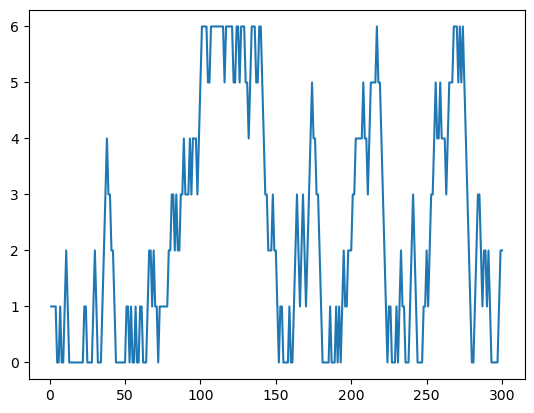

[1.0205543079618542, 1.0823483944586334, 0.0, 0.40831409839474475, 0.21302240571015887, 0.0, 0.0]


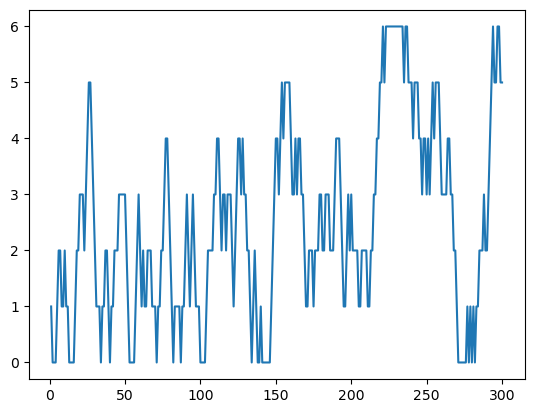

[1.1155543079618544, 1.0127174349667865, 0.8770778008259387, 0.7192045737068281, 0.4953177871531355, 0.0, 0.0]


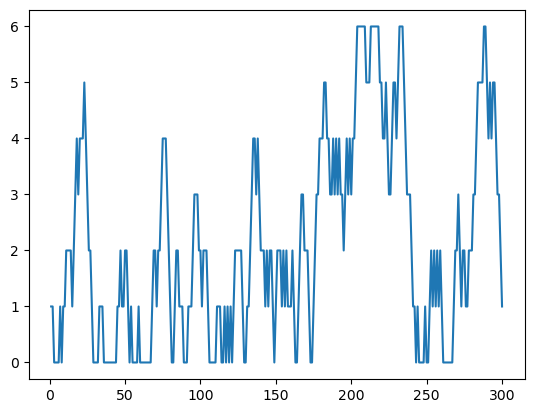

[0.9890543079618546, 0.0, 0.622473448828882, 0.0, 0.0, 0.0, 0.0]


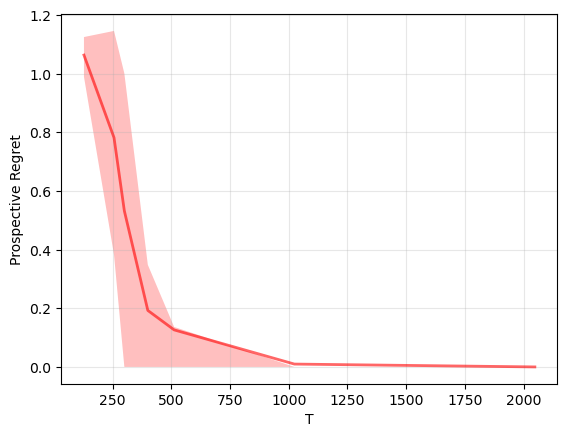

In [489]:
import xgboost as xgb
t_prime = 6
gamma = 0.5
# Ts = [128,256,300,400,512,1024]
Ts = [128,256,300,400,512,1024,2048]
# Train an initial model (could be your first batch with Option A)
REGRETS = []
for rep in range(20):
    pregrets = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                            session_duration = 100000,
                                                            tdim=50, 
                                                            n_sessions=1,
                                                            seed  = 8515 + rep
                                                            )
    plt.plot(np.arange(1,301),states[:300,0])
    plt.show()
    for T in Ts:
        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        X_train = new_state_oh[:T,:]
        Y_train = irewards[:T]

        dtrain = xgb.DMatrix(X_train, label=Y_train)
        params = {
            "objective": "reg:squarederror",
            "tree_method": "exact",
            "learning_rate": 0.05,
            "max_depth": 8,
            "booster": "gbtree",
            # "eval_metric":"rmse",
            # "n_estimators":1000
            
        }
        booster = xgb.train(params, dtrain, num_boost_round=1000)  # some initial trees
        num_trees = booster.num_boosted_rounds()
        # print(num_trees)
        
        current_state = states[T,0]
        # print(T,current_state)
        future_states = [current_state]
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))

            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                features = xgb.DMatrix(features)
                irewards_pred[:,i] = booster.predict(features)

            # # Convert to DataFrame for inspection
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
            # print(T+delta_t+1,current_state)
        # print(T,future_states,len(future_states))
        # FUTURE_STATE.append(future_states)

        irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_test,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        # print(pregret)
        pregrets.append(pregret)
        # plt.plot(np.arange(T+1,T+101),future_states[1:])
        # plt.plot(np.arange(T,T+101),path)
        # plt.show()
    REGRETS.append(pregrets)
    print(pregrets)


## XGBoost Offline
REGRETS_arr_offline = np.vstack(REGRETS)        # shape: (n_runs, T)  ← typical
if REGRETS_arr_offline.shape[0] == len(Ts):       # if you stacked along time by mistake
    REGRETS_arr_offline = REGRETS_arr_offline.T           # make axis=0 = runs, axis=1 = time

mean = np.nanmean(REGRETS_arr_offline, axis=0)    # (T,)
q25  = np.nanpercentile(REGRETS_arr_offline, 25, axis=0)
q75  = np.nanpercentile(REGRETS_arr_offline, 75, axis=0)

fig, ax = plt.subplots()
ax.plot(Ts, mean, lw=2,color = 'red',alpha = 0.6)
ax.fill_between(Ts, q25, q75, color='red', alpha=0.25, edgecolor="none")

ax.set_xlabel("T")
ax.set_ylabel("Prospective Regret")
ax.grid(True, alpha=0.3)

np.savez(
    f"../results/PAFM/XGB_oh_w_time128_2048_lookahead{t_prime}_reps{0}.npz",
    pregrests =REGRETS_arr_offline
    )

# Later batches: refresh leaves on existing trees
# batch = 300
# T_initial = 0
# for i in range(1):
#     t0 = T_initial + batch * i
#     t1 = T_initial + batch * (i + 1)
#     dnew = xgb.DMatrix(new_state_oh[t0:t1, :], label=irewards[t0:t1])
#     if i == 0:
#         num_boost_round = 100
#     else:
#         num_boost_round = 100

#     booster = xgb.train(
#         # params | {"process_type": "update", "updater": "refresh", "refresh_leaf": 1},
#         params,
#         dtrain=dnew,
#         num_boost_round=num_boost_round, 
#         xgb_model=booster
#     )
#     print("trees:", len(booster.get_dump()))

num_batch:  0
num_batch:  3
num_batch:  4
num_batch:  6
num_batch:  8
num_batch:  18
num_batch:  38
[1.5849438053209115, 1.28435207487406, 1.2578065844214847, 0.7668456871358805, 1.212143222791273, 1.797282881273408, 0.7916542877396515]
num_batch:  0
num_batch:  3
num_batch:  4
num_batch:  6
num_batch:  8
num_batch:  18
num_batch:  38
[1.0762493081108655, 1.2561347349263599, 1.1877806909602777, 1.2477806337398187, 1.1943656004161267, 1.2822095259002138, 1.1755543079618542]
num_batch:  0
num_batch:  3
num_batch:  4
num_batch:  6
num_batch:  8
num_batch:  18
num_batch:  38
[1.251348387557353, 1.165032138311683, 1.4412659077601404, 1.3453908167991873, 1.2810455504161269, 1.3505715015078041, 1.0655543079618541]
num_batch:  0
num_batch:  3
num_batch:  4
num_batch:  6
num_batch:  8
num_batch:  18
num_batch:  38
[1.1892779714209345, 1.1736186955686367, 1.1620969040153282, 1.2950496726403282, 1.1868069244166162, 1.1957216887158113, 1.2657779714209343]
num_batch:  0
num_batch:  3
num_batch:  4


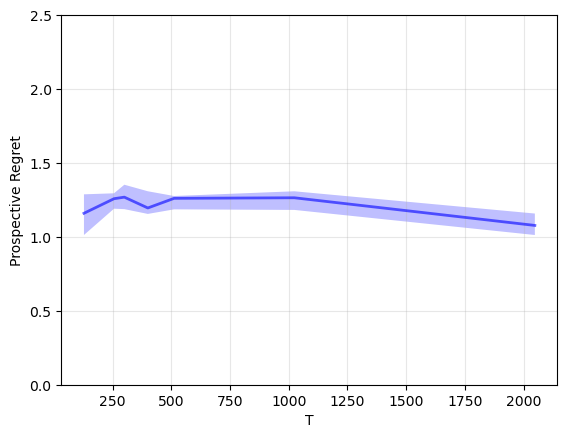

In [491]:
t_prime = 6
gamma = 0.5
# Ts = [128,256,300,400,512,1024]
Ts = [128,256,300,400,512,1024,2048]
T_initial = 100
# Train an initial model (could be your first batch with Option A)
REGRETS = []
for rep in range(20):
    pregrets = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                            session_duration = 100000,
                                                            tdim=50, 
                                                            n_sessions=1,
                                                            seed  = 8515 + rep
                                                            )
    # plt.plot(np.arange(1,301),states[:300,0])
    # plt.show()
    for T in Ts:
        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        X_train = new_state_oh[:T_initial,:]
        Y_train = irewards[:T_initial]

        dtrain = xgb.DMatrix(X_train, label=Y_train)
        params = {
            "objective": "reg:squarederror",
            "tree_method": "exact",
            "learning_rate": 0.05,
            "max_depth": 8,
            "booster": "gbtree",
            # "eval_metric":"rmse",
            # "n_estimators":1000
            
        }
        booster = xgb.train(params, dtrain, num_boost_round=1000)  # some initial trees
        num_trees = booster.num_boosted_rounds()
        # print(num_trees)
        # Later batches: refresh leaves on existing trees
        batch = 50
        num_batch = int((T-T_initial)/batch)
        print('num_batch: ',num_batch)
        for i in range(num_batch):
            t0 = T_initial + batch * i
            t1 = T_initial + batch * (i + 1)
            dnew = xgb.DMatrix(new_state_oh[t0:t1, :], label=irewards[t0:t1])
            if i == 0:
                num_boost_round = 0
            else:
                num_boost_round = 0

            booster = xgb.train(
                # params | {"process_type": "update", "updater": "refresh", "refresh_leaf": 1},
                params,
                dtrain=dnew,
                num_boost_round=num_boost_round, 
                xgb_model=booster
            )
            # print("trees:", len(booster.get_dump()))
                
        current_state = states[T,0]
        # print(T,current_state)
        future_states = [current_state]
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))

            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                features = xgb.DMatrix(features)
                irewards_pred[:,i] = booster.predict(features)

            # # Convert to DataFrame for inspection
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
            # print(T+delta_t+1,current_state)
        # print(T,future_states,len(future_states))
        # FUTURE_STATE.append(future_states)

        irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_test,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        # print(pregret)
        pregrets.append(pregret)
        # plt.plot(np.arange(T+1,T+101),future_states[1:])
        # plt.plot(np.arange(T,T+101),path)
        # plt.show()
    REGRETS.append(pregrets)
    print(pregrets)


## XGBoost Offline
REGRETS_arr_online_leave = np.vstack(REGRETS)        # shape: (n_runs, T)  ← typical
if REGRETS_arr_online_leave.shape[0] == len(Ts):       # if you stacked along time by mistake
    REGRETS_arr_online_leave = REGRETS_arr_online_leave.T           # make axis=0 = runs, axis=1 = time

mean = np.nanmean(REGRETS_arr_online_leave, axis=0)    # (T,)
q25  = np.nanpercentile(REGRETS_arr_online_leave, 25, axis=0)
q75  = np.nanpercentile(REGRETS_arr_online_leave, 75, axis=0)

fig, ax = plt.subplots()
ax.plot(Ts, mean, lw=2,color = 'blue',alpha = 0.6)
ax.fill_between(Ts, q25, q75, color='blue', alpha=0.25, edgecolor="none")

ax.set_xlabel("T")
ax.set_ylabel("Prospective Regret")
ax.set_ylim(0, 2.5) 
ax.grid(True, alpha=0.3)


# Later batches: refresh leaves on existing trees
# batch = 300
# T_initial = 0
# for i in range(1):
#     t0 = T_initial + batch * i
#     t1 = T_initial + batch * (i + 1)
#     dnew = xgb.DMatrix(new_state_oh[t0:t1, :], label=irewards[t0:t1])
#     if i == 0:
#         num_boost_round = 100
#     else:
#         num_boost_round = 100

#     booster = xgb.train(
#         # params | {"process_type": "update", "updater": "refresh", "refresh_leaf": 1},
#         params,
#         dtrain=dnew,
#         num_boost_round=num_boost_round, 
#         xgb_model=booster
#     )
#     print("trees:", len(booster.get_dump()))

num_batch:  0
num_batch:  3
num_batch:  4
num_batch:  6
num_batch:  8
num_batch:  18
num_batch:  38
[1.5849438053209115, 1.0564731465584987, 1.8536712528485588, 1.5082733223571894, 1.8554560125511592, 1.9420533516306653, 1.9720112099666574]
num_batch:  0
num_batch:  3
num_batch:  4
num_batch:  6
num_batch:  8
num_batch:  18
num_batch:  38
[1.0762493081108655, 1.4423057299563382, 1.2535369443399258, 1.3993711586997215, 1.6205778348007407, 1.263094786318088, 1.2660437379474714]
num_batch:  0
num_batch:  3
num_batch:  4
num_batch:  6
num_batch:  8
num_batch:  18
num_batch:  38
[1.3720838735213732, 1.4129811275553987, 0.7621037601007231, 0.8727744545749471, 1.0871300942676865, 1.2815514948156448, 1.4696484160517886]
num_batch:  0
num_batch:  3
num_batch:  4
num_batch:  6
num_batch:  8
num_batch:  18
num_batch:  38
[1.1919653570209343, 1.299880970289877, 1.6060344412297576, 1.4460695410118058, 2.0114015321171768, 1.4031878673442884, 1.253927180794015]
num_batch:  0
num_batch:  3
num_batch: 

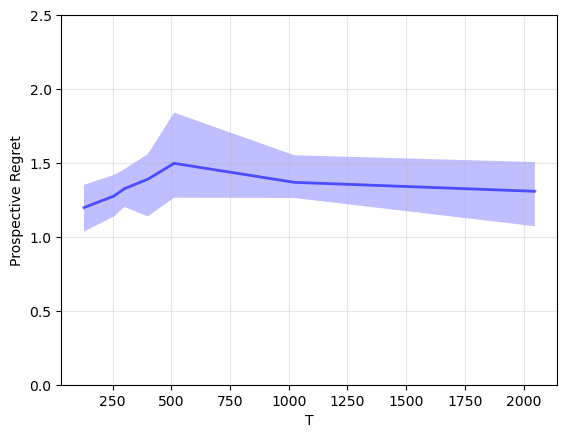

In [492]:
t_prime = 6
gamma = 0.5
# Ts = [128,256,300,400,512,1024]
Ts = [128,256,300,400,512,1024,2048]
T_initial = 100
# Train an initial model (could be your first batch with Option A)
REGRETS = []
for rep in range(20):
    pregrets = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                            session_duration = 100000,
                                                            tdim=50, 
                                                            n_sessions=1,
                                                            seed  = 8515 + rep
                                                            )
    # plt.plot(np.arange(1,301),states[:300,0])
    # plt.show()
    for T in Ts:
        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        X_train = new_state_oh[:T_initial,:]
        Y_train = irewards[:T_initial]

        dtrain = xgb.DMatrix(X_train, label=Y_train)
        params = {
            "objective": "reg:squarederror",
            "tree_method": "exact",
            "learning_rate": 0.05,
            "max_depth": 8,
            "booster": "gbtree",
            # "eval_metric":"rmse",
            # "n_estimators":1000
            
        }
        booster = xgb.train(params, dtrain, num_boost_round=100)  # some initial trees
        num_trees = booster.num_boosted_rounds()
        # print(num_trees)
        # Later batches: refresh leaves on existing trees
        batch = 50
        num_batch = int((T-T_initial)/batch)
        print('num_batch: ',num_batch)
        for i in range(num_batch):
            t0 = T_initial + batch 
            t1 = T_initial + batch * (i + 1)
            dnew = xgb.DMatrix(new_state_oh[t0:t1, :], label=irewards[t0:t1])
            if i == 0:
                num_boost_round = 100
            elif i > 9:
                num_boost_round = 0
            else:
                num_boost_round = 100

            booster = xgb.train(
                # params | {"process_type": "update", "updater": "refresh", "refresh_leaf": 1},
                params,
                dtrain=dnew,
                num_boost_round=num_boost_round, 
                xgb_model=booster
            )
            # print("trees:", len(booster.get_dump()))
                
        current_state = states[T,0]
        # print(T,current_state)
        future_states = [current_state]
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))

            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                features = xgb.DMatrix(features)
                irewards_pred[:,i] = booster.predict(features)

            # # Convert to DataFrame for inspection
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
            # print(T+delta_t+1,current_state)
        # print(T,future_states,len(future_states))
        # FUTURE_STATE.append(future_states)

        irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_test,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        # print(pregret)
        pregrets.append(pregret)
        # plt.plot(np.arange(T+1,T+101),future_states[1:])
        # plt.plot(np.arange(T,T+101),path)
        # plt.show()
    REGRETS.append(pregrets)
    print(pregrets)


## XGBoost Offline
REGRETS_arr_online_tree = np.vstack(REGRETS)        # shape: (n_runs, T)  ← typical
if REGRETS_arr_online_tree.shape[0] == len(Ts):       # if you stacked along time by mistake
    REGRETS_arr_online_tree = REGRETS_arr_online_tree.T           # make axis=0 = runs, axis=1 = time

mean = np.nanmean(REGRETS_arr_online_tree, axis=0)    # (T,)
q25  = np.nanpercentile(REGRETS_arr_online_tree, 25, axis=0)
q75  = np.nanpercentile(REGRETS_arr_online_tree, 75, axis=0)

fig, ax = plt.subplots()
ax.plot(Ts, mean, lw=2,color = 'blue',alpha = 0.6)
ax.fill_between(Ts, q25, q75, color='blue', alpha=0.25, edgecolor="none")

ax.set_xlabel("T")
ax.set_ylabel("Prospective Regret")
ax.set_ylim(0, 2.5) 
ax.grid(True, alpha=0.3)


# Later batches: refresh leaves on existing trees
# batch = 300
# T_initial = 0
# for i in range(1):
#     t0 = T_initial + batch * i
#     t1 = T_initial + batch * (i + 1)
#     dnew = xgb.DMatrix(new_state_oh[t0:t1, :], label=irewards[t0:t1])
#     if i == 0:
#         num_boost_round = 100
#     else:
#         num_boost_round = 100

#     booster = xgb.train(
#         # params | {"process_type": "update", "updater": "refresh", "refresh_leaf": 1},
#         params,
#         dtrain=dnew,
#         num_boost_round=num_boost_round, 
#         xgb_model=booster
#     )
#     print("trees:", len(booster.get_dump()))s

In [1]:
fig, ax = plt.subplots(figsize=(18, 6))
fontsize = 20
linewidth = 4

mean = np.nanmean(REGRETS_arr_offline, axis=0)    
q25  = np.nanpercentile(REGRETS_arr_offline, 25, axis=0)
q75  = np.nanpercentile(REGRETS_arr_offline, 75, axis=0)
ax.plot(Ts, mean, lw=2,color = 'red',alpha = 0.6,label = 'XGB-offline')
ax.fill_between(Ts, q25, q75, color='red', alpha=0.25, edgecolor="none")


mean = np.nanmean(REGRETS_arr_online_leave, axis=0)   
q25  = np.nanpercentile(REGRETS_arr_online_leave, 25, axis=0)
q75  = np.nanpercentile(REGRETS_arr_online_leave, 75, axis=0)
ax.plot(Ts, mean, lw=2,color = 'blue',alpha = 0.6,label = 'XGB-online',lw = linewidth)
ax.fill_between(Ts, q25, q75, color='blue', alpha=0.25, edgecolor="none",lw = linewidth)

# mean = np.nanmean(REGRETS_arr_online_tree, axis=0)   
# q25  = np.nanpercentile(REGRETS_arr_online_tree, 25, axis=0)
# q75  = np.nanpercentile(REGRETS_arr_online_tree, 75, axis=0)
# ax.plot(Ts, mean, lw=2,color = 'green',alpha = 0.6,label = 'XGB-online-tree')
# ax.fill_between(Ts, q25, q75, color='green', alpha=0.25, edgecolor="none")


ax.set_xlabel("T",fontsize = fontsize)
ax.set_ylabel("Normalized Prospective Regret",fontsize=fontsize)
plt.xscale('log')
plt.title('Prospective Regret Across Lookahead Steps - PAFM Online',fontsize = fontsize)
xticks = Ts
xticklabels = [str(v) if v in [128,256,512,1024,2048,5000] else ""   # hide every 2nd label
               for i, v in enumerate(xticks)]
plt.xticks(xticks, labels=xticklabels,fontsize = fontsize-5)
plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
ax.set_ylim(0, 2.5) 
ax.grid(True, alpha=0.2)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5),fontsize = fontsize-5)
plt.show()


NameError: name 'plt' is not defined

1000 5.0
1000 [np.float64(5.0), 4, 3, 2, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


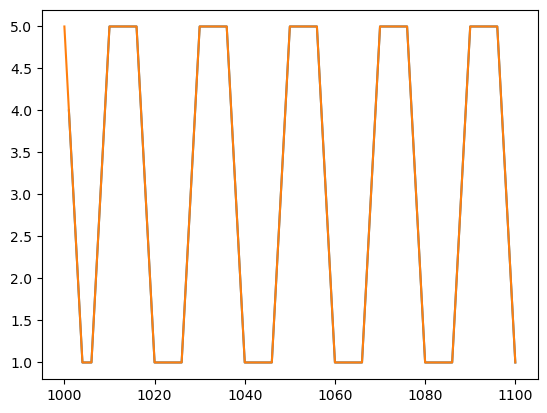

In [456]:
T = 1000
t_prime = 6
gamma = 0.5
current_state = states[T,0]
print(T,current_state)
future_states = [current_state]
for delta_t in range(100):
    df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  t_prime+1))

    for i in range(t_prime+1):
        cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
        curr_time = T+1+delta_t+i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
        features = np.hstack([cand_pe,time_emb])
        features = xgb.DMatrix(features)
        irewards_pred[:,i] = booster.predict(features)

    # # Convert to DataFrame for inspection
    reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    # Extract rewards from second column onward (t=1 to t=T)
    rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
    discounts = gamma ** np.arange(1, t_prime+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)
    bext_idx = np.argmax(total_discounted)
    next_state = int(df_all_paths.iloc[bext_idx,1])
    # print(df_all_paths.iloc[bext_idx,:])
    future_states.append(next_state)
    current_state = next_state
    # print(T+delta_t+1,current_state)
print(T,future_states,len(future_states))
# FUTURE_STATE.append(future_states)

irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
preward = compute_normalized_future_rewards(irewards_test,100,0.5)
path, ireward_opt = path_opt(future_states[0], T, 100)
preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
print(pregret)
plt.plot(np.arange(T+1,T+101),future_states[1:])
plt.plot(np.arange(T,T+101),path)
plt.show()

# Offline - GBT

128 0.0
128 [np.float64(0.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
0.9890543079618546


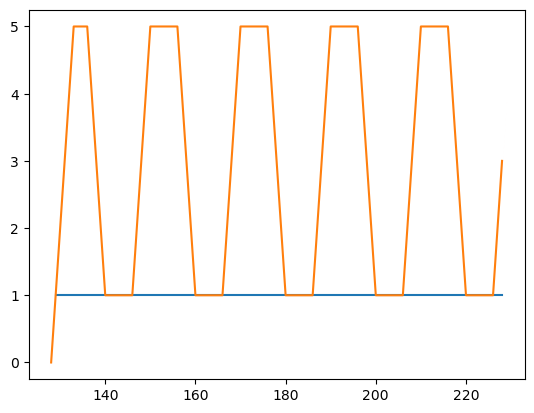

150 0.0
150 [np.float64(0.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.0621819083200776


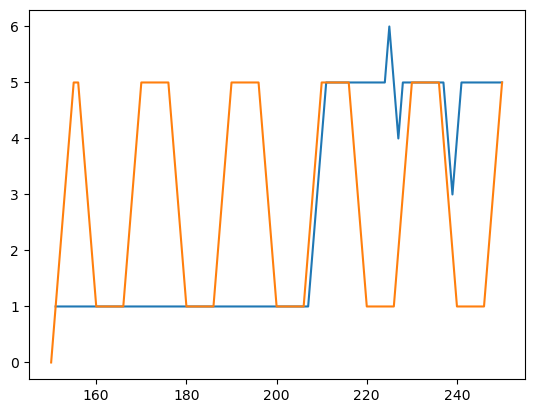

175 0.0
175 [np.float64(0.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4] 101
1.1997756451963524


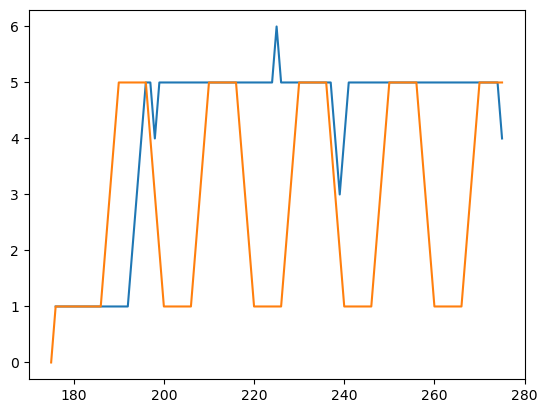

200 0.0
200 [np.float64(0.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 4, 5, 5, 4, 3, 2, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 5, 5, 4, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.440065543064531


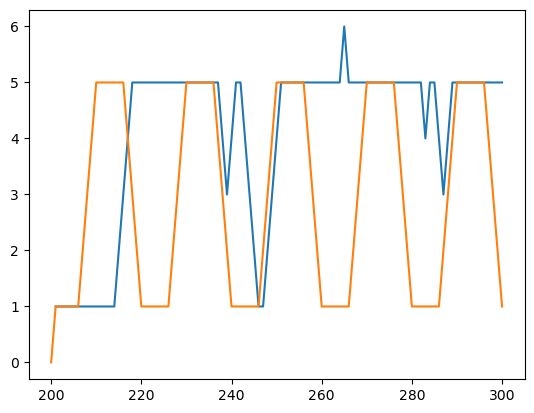

225 0.0
225 [np.float64(0.0), 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1] 101
0.5637659375463869


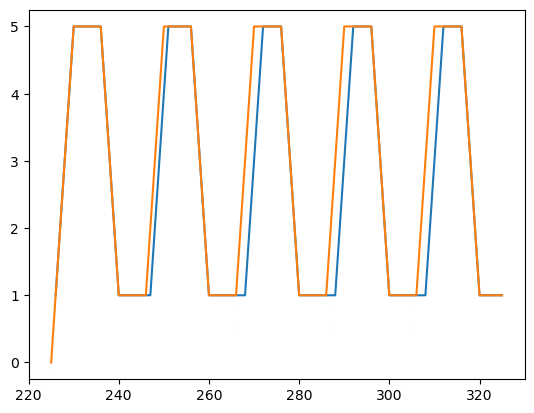

256 2.0
256 [np.float64(2.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5] 101
0.8041482360280671


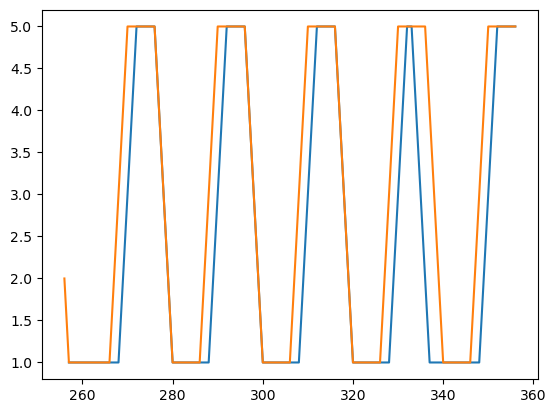

512 4.0
512 [np.float64(4.0), 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.0


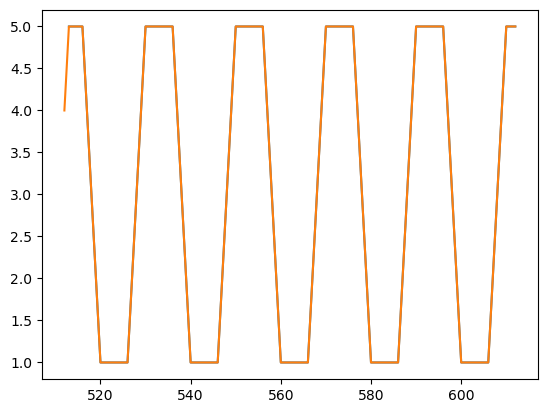

750 6.0
750 [np.float64(6.0), 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


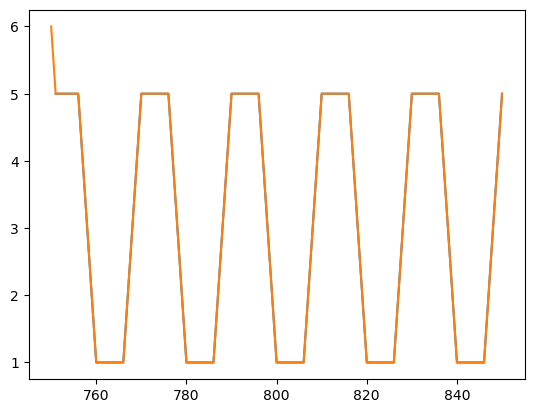

1024 0.0
1024 [np.float64(0.0), 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


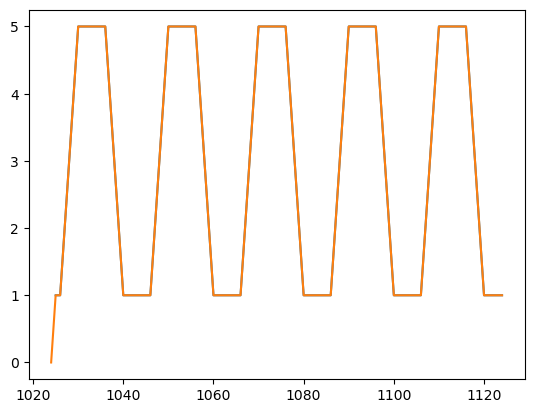

1250 2.0
1250 [np.float64(2.0), 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


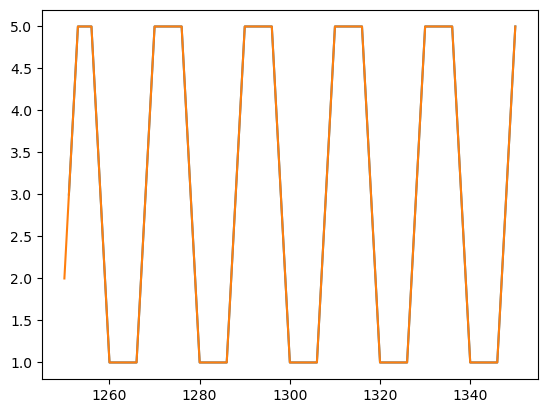

1500 4.0
1500 [np.float64(4.0), 3, 2, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


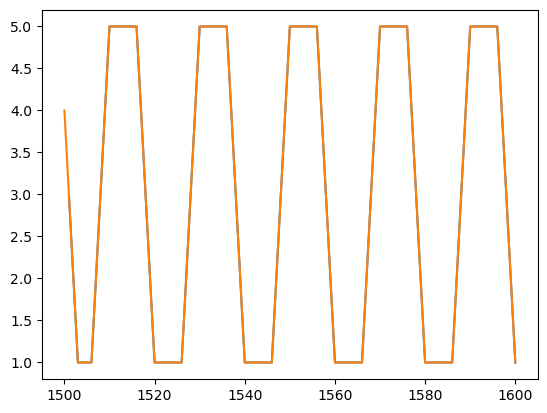

2048 0.0
2048 [np.float64(0.0), 1, 2, 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


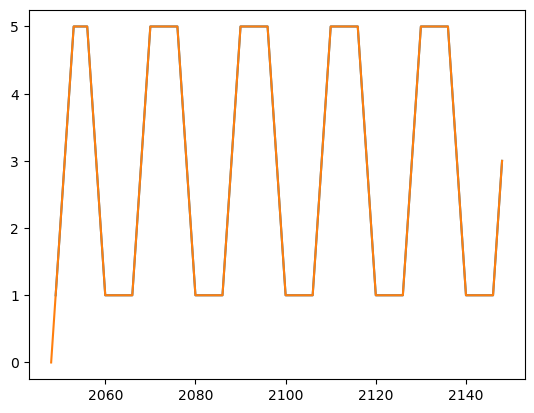

In [187]:
# T_initial = 200
t_prime = 6
gamma = 0.5
actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 100000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 980515)
for T_initial in [2**i for i in np.arange(7,8)]+[150,175,200,225]+[2**i for i in np.arange(8,10)]+[750]+[1024,1250,1500,2048]:
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    X_train = new_state_oh[:T_initial,:]
    Y_train = irewards[:T_initial]
    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        tree_method="exact",     # or "exact" (slower, RAM heavy)
        n_jobs = -1,
        learning_rate=0.01, max_depth=10,
        subsample=1, colsample_bytree=0.8,
        n_estimators=1000, eval_metric="rmse"
    )
    model.fit(X_train, Y_train)
    T = T_initial
    current_state = states[T,0]
    print(T,current_state)
    future_states = [current_state]
    for delta_t in range(100):
        df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
        n_paths = df_all_paths.shape[0]
        irewards_pred = np.zeros((n_paths,  t_prime+1))

        for i in range(t_prime+1):
            cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
            curr_time = T+1+delta_t+i
            time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
            features = np.hstack([cand_pe,time_emb])
            irewards_pred[:,i] = model.predict(features)

        # # Convert to DataFrame for inspection
        reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
        df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
        # Extract rewards from second column onward (t=1 to t=T)
        rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
        discounts = gamma ** np.arange(1, t_prime+1)

        # Compute discounted total reward per path
        discounted_returns = rewards_matrix * discounts  
        total_discounted = discounted_returns.sum(axis=1)
        # print(total_discounted)
        bext_idx = np.argmax(total_discounted)
        next_state = int(df_all_paths.iloc[bext_idx,1])
        # print(df_all_paths.iloc[bext_idx,:])
        future_states.append(next_state)
        current_state = next_state
        # print(T+delta_t+1,current_state)
    print(T,future_states,len(future_states))
    # FUTURE_STATE.append(future_states)

    irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
    preward = compute_normalized_future_rewards(irewards_test,100,0.5)
    path, ireward_opt = path_opt(future_states[0], T, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
    pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
    print(pregret)
    plt.plot(np.arange(T+1,T+101),future_states[1:])
    plt.plot(np.arange(T,T+101),path)
    plt.show()

# Online with Hoeffding Trees

In [267]:
from river import tree, metrics
def predict_numpy(gb, X_test):
    y_pred = []
    for i in range(X_test.shape[0]):
        X_test_idx = np.array(new_state_oh[i,:].reshape(-1),dtype=np.float32)
        X_test_idx_dict = {f"f{i}": float(v) for i, v in enumerate(X_test_idx)}
        y_pred_idx = gb.predict_one(X_test_idx_dict)
        y_pred.append(y_pred_idx)
    return np.array(y_pred, dtype=float)

# A Hoeffding Tree for regression
model = tree.HoeffdingTreeRegressor(
    grace_period=50,       # min samples before checking for a split
    delta=1e-7, 
    tau = 0.05
    # max_depth=10
)
# X0 =np.array(new_state_oh[0,:],dtype=np.float32)
# X0 = {f"f{i}": float(v) for i, v in enumerate(Xn)}
# y0 = irewards[0]
# model.learn_one(X0, y0)     
T_initial = 0
rmse_metric = metrics.RMSE() 
batch = 1
for i in range(5000):
    t_initial = T_initial+batch*i
    t_end = T_initial+batch*(i+1)
    print(t_initial,t_end)
    Xn = np.array(new_state_oh[t_initial:t_end,:].reshape(-1),dtype=np.float32)

    Xn_dict = {f"f{i}": float(v) for i, v in enumerate(Xn)}
    yn = float(irewards[t_initial:t_end])
    y_pred = model.predict_one(Xn_dict)
    # rmse_metric.update(yn, y_pred)  # evaluation only
    model.learn_one(Xn_dict, yn)          # <-- immediate online update

0 1
1 2
2 3
3 4
4 5
5 6
6 7
7 8
8 9
9 10
10 11
11 12
12 13
13 14
14 15
15 16
16 17
17 18
18 19
19 20
20 21
21 22
22 23
23 24
24 25
25 26
26 27
27 28
28 29
29 30
30 31
31 32
32 33
33 34
34 35
35 36
36 37
37 38
38 39
39 40
40 41
41 42
42 43
43 44
44 45
45 46
46 47
47 48
48 49
49 50
50 51
51 52
52 53
53 54
54 55
55 56
56 57
57 58
58 59
59 60
60 61
61 62
62 63
63 64
64 65
65 66
66 67
67 68
68 69
69 70
70 71
71 72
72 73
73 74
74 75
75 76
76 77
77 78
78 79
79 80
80 81
81 82
82 83
83 84
84 85
85 86
86 87
87 88
88 89
89 90
90 91
91 92
92 93
93 94
94 95
95 96
96 97
97 98
98 99
99 100
100 101
101 102
102 103
103 104
104 105
105 106
106 107
107 108
108 109
109 110
110 111
111 112
112 113
113 114
114 115
115 116
116 117
117 118
118 119
119 120
120 121
121 122
122 123
123 124
124 125
125 126
126 127
127 128
128 129
129 130
130 131
131 132
132 133
133 134
134 135
135 136
136 137
137 138
138 139
139 140
140 141
141 142
142 143
143 144
144 145
145 146
146 147
147 148
148 149
149 150
150 151
151 152
15

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_73239/3381220085.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yn = float(irewards[t_initial:t_end])


583 584
584 585
585 586
586 587
587 588
588 589
589 590
590 591
591 592
592 593
593 594
594 595
595 596
596 597
597 598
598 599
599 600
600 601
601 602
602 603
603 604
604 605
605 606
606 607
607 608
608 609
609 610
610 611
611 612
612 613
613 614
614 615
615 616
616 617
617 618
618 619
619 620
620 621
621 622
622 623
623 624
624 625
625 626
626 627
627 628
628 629
629 630
630 631
631 632
632 633
633 634
634 635
635 636
636 637
637 638
638 639
639 640
640 641
641 642
642 643
643 644
644 645
645 646
646 647
647 648
648 649
649 650
650 651
651 652
652 653
653 654
654 655
655 656
656 657
657 658
658 659
659 660
660 661
661 662
662 663
663 664
664 665
665 666
666 667
667 668
668 669
669 670
670 671
671 672
672 673
673 674
674 675
675 676
676 677
677 678
678 679
679 680
680 681
681 682
682 683
683 684
684 685
685 686
686 687
687 688
688 689
689 690
690 691
691 692
692 693
693 694
694 695
695 696
696 697
697 698
698 699
699 700
700 701
701 702
702 703
703 704
704 705
705 706
706 707
707 708


6000 5.0
6000 [np.float64(5.0), 4, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2] 101
2.3709798883886903


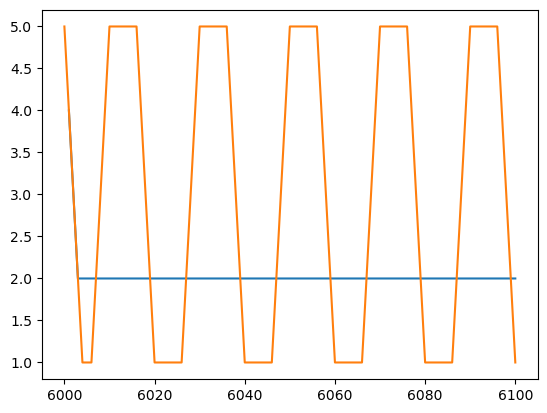

In [268]:
T = 6000
t_prime = 6
gamma = 0.5
current_state = states[T,0]
print(T,current_state)
future_states = [current_state]
for delta_t in range(100):
    df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  t_prime+1))

    for i in range(t_prime+1):
        cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
        curr_time = T+1+delta_t+i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
        features = np.hstack([cand_pe,time_emb])
        irewards_pred[:,i] = predict_numpy(model, features)
    # # Convert to DataFrame for inspection
    reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    # Extract rewards from second column onward (t=1 to t=T)
    rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
    discounts = gamma ** np.arange(1, t_prime+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)
    bext_idx = np.argmax(total_discounted)
    next_state = int(df_all_paths.iloc[bext_idx,1])
    # print(df_all_paths.iloc[bext_idx,:])
    future_states.append(next_state)
    current_state = next_state
    # print(T+delta_t+1,current_state)
print(T,future_states,len(future_states))
# FUTURE_STATE.append(future_states)

irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
preward = compute_normalized_future_rewards(irewards_test,100,0.5)
path, ireward_opt = path_opt(future_states[0], T, 100)
preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
print(pregret)
plt.plot(np.arange(T+1,T+101),future_states[1:])
plt.plot(np.arange(T,T+101),path)
plt.show()

In [260]:
# -------- online_boosted_forest_mse.py --------
from typing import Callable, Any, Dict, Optional
from river import tree, metrics
import numpy as np

# ---------- Loss (MSE / Squared) ----------
class Loss:
    def gradient(self, y_true: float, y_pred: float) -> float:
        raise NotImplementedError
    def hessian(self, y_true: float, y_pred: float) -> Optional[float]:
        return None

class SquaredLoss(Loss):
    # per-sample: 0.5 * (y - y_pred)^2
    def gradient(self, y_true, y_pred):  # dℓ/dŷ
        return (y_pred - y_true)
    def hessian(self, y_true, y_pred):
        return 1.0

# ---------- Online Gradient Boosting (Regressor) ----------
class OnlineGBTRegressor:
    """
    Boosts online base learners by fitting to negative gradients (pseudo-residuals).
    Works in a single pass: predict -> compute grad at current F(x) -> learn_one.
    """
    def __init__(
        self,
        base_learner_factory: Callable[[], Any],
        n_estimators: int = 30,
        learning_rate: float = 0.05,
        loss: Loss = None,
        use_newton_step: bool = True,
        min_hessian: float = 1e-6,
        bias_lr: float = 0.02,
    ):
        self.make = base_learner_factory
        self.models = [self.make() for _ in range(n_estimators)]
        self.nu = learning_rate
        self.loss = loss if loss is not None else SquaredLoss()
        self.use_newton = use_newton_step
        self.min_hessian = min_hessian
        self.F0 = 0.0
        self.bias_lr = bias_lr

    def predict_one(self, x: Dict) -> float:
        F = self.F0
        for m in self.models:
            F += self.nu * m.predict_one(x)
        return F

    def learn_one(self, x: Dict, y: float) -> None:
        # current ensemble prediction
        F = self.predict_one(x)
        # small bias update (helps early steps)
        g0 = self.loss.gradient(y, F)
        self.F0 -= self.bias_lr * g0

        # stage-wise updates down the booster chain
        F_running = F
        for m in self.models:
            g = self.loss.gradient(y, F_running)   # dℓ/dF at current F
            target = -g                             # pseudo-residual
            if self.use_newton:
                h = self.loss.hessian(y, F_running)
                if h is not None and h > self.min_hessian:
                    target = target / h            # Newton step (safe for MSE)
            m.learn_one(x, target)
            F_running += self.nu * m.predict_one(x)

# ---------- Base learner: Hoeffding Tree (your params) ----------
def make_tree():
    return tree.HoeffdingTreeRegressor(
        grace_period=30,       # try 30–100 for responsiveness
        delta=1e-7,            # stricter split confidence
        tau=0.05,              # tie threshold
        leaf_prediction="mean" # or "model" for stronger per-leaf fits
    )

# ---------- Helper: row -> dict ----------
def row_to_dict(row_1d) -> Dict[str, float]:
    return {f"f{i}": float(v) for i, v in enumerate(np.asarray(row_1d).ravel())}

# ---------- Example: plug your arrays into boosted trees ----------
def train_boosted_forest(new_state_oh: np.ndarray, irewards: np.ndarray):
    """
    new_state_oh: shape (N, D) features
    irewards:     shape (N,) targets
    """
    gbt = OnlineGBTRegressor(
        base_learner_factory=make_tree,   # << boosted trees
        n_estimators=1000,
        learning_rate=0.05,
        loss=SquaredLoss(),
        use_newton_step=True              # fine for MSE (Hessian=1)
    )

    rmse = metrics.RMSE()
    N = len(irewards)

    for i in range(N):
        x_dict = row_to_dict(new_state_oh[i, :])  # one sample as dict
        y_true = float(irewards[i])

        # evaluate BEFORE learning (streaming eval)
        y_pred = gbt.predict_one(x_dict)
        rmse.update(y_true, y_pred)

        # one-step online update
        gbt.learn_one(x_dict, y_true)

        # (optional) print a heartbeat
        # if (i+1) % 1000 == 0:
        #     print(f"i={i+1}, RMSE={rmse.get():.4f}")

    print(f"Final streaming RMSE (pre-update view): {rmse.get():.4f}")
    return gbt

# # ---------- Inference example ----------
# if __name__ == "__main__":
#     # Dummy demo if you just run this file:
#     rng = np.random.default_rng(0)
#     N, D = 5000, 8
#     X = rng.normal(size=(N, D))
#     y = 2*X[:, 0] - 3*X[:, 1] + rng.normal(scale=0.3, size=N)

#     model = train_boosted_forest(X, y)

#     test_row = np.array([0.7, -1.2] + [0.0]*(D-2))
#     print("Prediction on test_row:", model.predict_one(row_to_dict(test_row)))

In [261]:
T_initial = 1000
X_train = new_state_oh[:T_initial,:]
Y_train = irewards[:T_initial]
model = train_boosted_forest(X_train, Y_train)

KeyboardInterrupt: 

In [271]:
from river import ensemble
model = ensemble.AdaptiveBoostingClassifier(
    model=tree.HoeffdingTreeClassifier(),
    n_models=10
)
rmse_metric = metrics.RMSE() 
batch = 1
for i in range(5000):
    t_initial = T_initial+batch*i
    t_end = T_initial+batch*(i+1)
    # print(t_initial,t_end)
    Xn = np.array(new_state_oh[t_initial:t_end,:].reshape(-1),dtype=np.float32)

    Xn_dict = {f"f{i}": float(v) for i, v in enumerate(Xn)}
    yn = float(irewards[t_initial:t_end])
    y_pred = model.predict_one(Xn_dict)
    # rmse_metric.update(yn, y_pred)  # evaluation only
    model.learn_one(Xn_dict, yn)          # <-- immediate online update

AttributeError: module 'river.ensemble' has no attribute 'AdaptiveBoostingClassifier'